# Rainfall Climatology Analysis with Google Earth Engine

**Objective:** Compute the average number of rainy days per month using 42 years of CHIRPS daily precipitation data (1981–2023) via cloud-based geospatial processing.

**Technologies:** Google Earth Engine Python API, geemap, rasterio, matplotlib


## 1. Environment Setup

In [1]:
!pip install earthengine-api --upgrade
!pip install geemap
!pip install pycrs
!pip install rasterio

In [2]:
import sys
sys.path.insert(0, '..')

import ee
import geemap
import calendar
import numpy as np
import pymannkendall as mk

from src.gee_processing import (
    load_chirps,
    create_rainy_day_mask,
    compute_monthly_rainy_days,
    compute_climatology,
    clip_collection,
    extract_monthly_values,
    compute_annual_rainy_days,
    extract_annual_values,
    compute_threshold_climatology,
)
from src.plotting import (
    plot_annual_trend,
    plot_monthly_trends,
    plot_seasonal_distributions,
    plot_threshold_stacked_bar,
    plot_dataset_comparison,
)

ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='ee-chirps-analysis')

## 2. Data Processing Pipeline

### 2.1 Load Data and Compute Climatology

In [3]:
START_YEAR = 1981
END_YEAR = 2023

years = ee.List.sequence(START_YEAR, END_YEAR)
months = ee.List.sequence(1, 12)

# Load CHIRPS and create rainy day binary collection
chirps = load_chirps(START_YEAR, END_YEAR)
rainy_days_collection = chirps.map(create_rainy_day_mask).select('rainy_day')

print(f'CHIRPS collection size: {chirps.size().getInfo()} images')

CHIRPS collection size: 15704 images


In [4]:
# Compute monthly rainy day totals (42 years × 12 months = 504 images)
monthly_rainy_days = compute_monthly_rainy_days(rainy_days_collection, years, months)
print(f'Monthly rainy days collection: {monthly_rainy_days.size().getInfo()} images')

Monthly rainy days collection: 516 images


In [5]:
# Compute 12-month climatology and clip to AOI
mean_monthly_rainy_days = compute_climatology(monthly_rainy_days, months)
aoi = geemap.shp_to_ee('../data/aoi.shp')
climatology_clipped = clip_collection(mean_monthly_rainy_days, aoi)

print(f'Climatology: {mean_monthly_rainy_days.size().getInfo()} monthly images, clipped to AOI')

Climatology: 12 monthly images, clipped to AOI


## 3. Interactive Map

In [37]:
VIS_PARAMS = {
    'min': 0,
    'max': 6,
    'palette': ['#ffffcc', '#7eccba', '#41b7c4', '#2c80b8', '#253494', '#662A00']
}

Map = geemap.Map()
month_names = list(calendar.month_name)
images_list = climatology_clipped.toList(climatology_clipped.size())

for i in range(12):
    image = ee.Image(images_list.get(i))
    Map.addLayer(image, VIS_PARAMS, f'Avg Rainy Days - {month_names[i+1]}')

Map.add_colorbar_branca(
    colors=VIS_PARAMS['palette'],
    vmin=VIS_PARAMS['min'],
    vmax=VIS_PARAMS['max'],
    categorical=True,
    step=VIS_PARAMS['max'],
    layer_name='Rainy Days'
)
Map.centerObject(aoi, zoom=7)
Map

Map(center=[43.021711071903255, 107.24016043721427], controls=(WidgetControl(options=['position', 'transparent…

## 4. Trend Analysis (Mann-Kendall Test)

Detect statistically significant trends in annual rainy day counts over the 42-year period.

In [6]:
# Compute and extract annual rainy day totals
annual_rainy_days = compute_annual_rainy_days(rainy_days_collection, years)
annual_values = extract_annual_values(annual_rainy_days, END_YEAR - START_YEAR + 1, aoi)

annual_values_clean = np.array([v for v in annual_values if v is not None], dtype=float)
years_clean = np.arange(START_YEAR, START_YEAR + len(annual_values_clean))

# Run Mann-Kendall test
mk_result = mk.original_test(annual_values_clean)

print('=== Mann-Kendall Trend Test Results ===')
print(f'Trend:       {mk_result.trend}')
print(f'p-value:     {mk_result.p:.6f}')
print(f'Tau:         {mk_result.Tau:.4f}')
print(f"Sen's slope: {mk_result.slope:.4f} days/year")
print(f'Significant (α=0.05): {"Yes" if mk_result.p < 0.05 else "No"}')

=== Mann-Kendall Trend Test Results ===
Trend:       no trend
p-value:     0.094039
Tau:         0.1783
Sen's slope: 0.1036 days/year
Significant (α=0.05): No


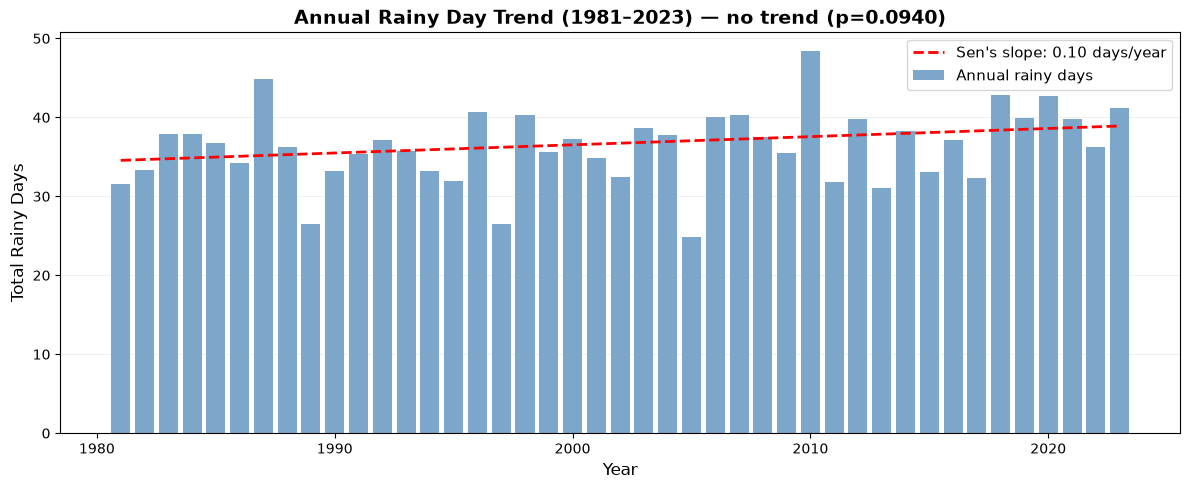

In [8]:
plot_annual_trend(years_clean, annual_values_clean, mk_result, START_YEAR, END_YEAR,
                  output_path='../plots/annual_trend_mann_kendall.png')

### 4.1 Monthly Trend Analysis

Test each calendar month individually to identify which months drive the overall trend.

In [9]:
monthly_trends = []

for m in range(1, 13):
    monthly_values = []
    for i in range(END_YEAR - START_YEAR + 1):
        idx = i * 12 + (m - 1)
        img = ee.Image(monthly_rainy_days.toList(monthly_rainy_days.size()).get(idx))
        mean_val = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi.geometry(),
            scale=5566,
            maxPixels=1e9
        ).get('rainy_day')
        monthly_values.append(mean_val)

    values = ee.List(monthly_values).getInfo()
    values_clean = np.array([v for v in values if v is not None], dtype=float)

    if len(values_clean) > 10:
        result = mk.original_test(values_clean)
        monthly_trends.append({
            'month': calendar.month_abbr[m],
            'trend': result.trend,
            'p_value': result.p,
            'slope': result.slope,
            'tau': result.Tau
        })
        print(f'{calendar.month_abbr[m]:>3}: {result.trend:<12} slope={result.slope:+.3f} days/yr  '
              f'p={result.p:.4f}  tau={result.Tau:+.3f}')

Jan: no trend     slope=+0.003 days/yr  p=0.9499  tau=+0.008
Feb: no trend     slope=-0.001 days/yr  p=0.9333  tau=-0.010
Mar: no trend     slope=+0.004 days/yr  p=0.9001  tau=+0.014
Apr: no trend     slope=+0.002 days/yr  p=0.9666  tau=+0.006
May: no trend     slope=-0.007 days/yr  p=0.7535  tau=-0.034
Jun: no trend     slope=-0.009 days/yr  p=0.4638  tau=-0.079
Jul: increasing   slope=+0.023 days/yr  p=0.0001  tau=+0.413
Aug: no trend     slope=+0.011 days/yr  p=0.1547  tau=+0.152
Sep: no trend     slope=+0.005 days/yr  p=0.3252  tau=+0.105
Oct: no trend     slope=-0.002 days/yr  p=0.8506  tau=-0.021
Nov: no trend     slope=+0.029 days/yr  p=0.0719  tau=+0.192
Dec: no trend     slope=-0.008 days/yr  p=0.7695  tau=-0.032


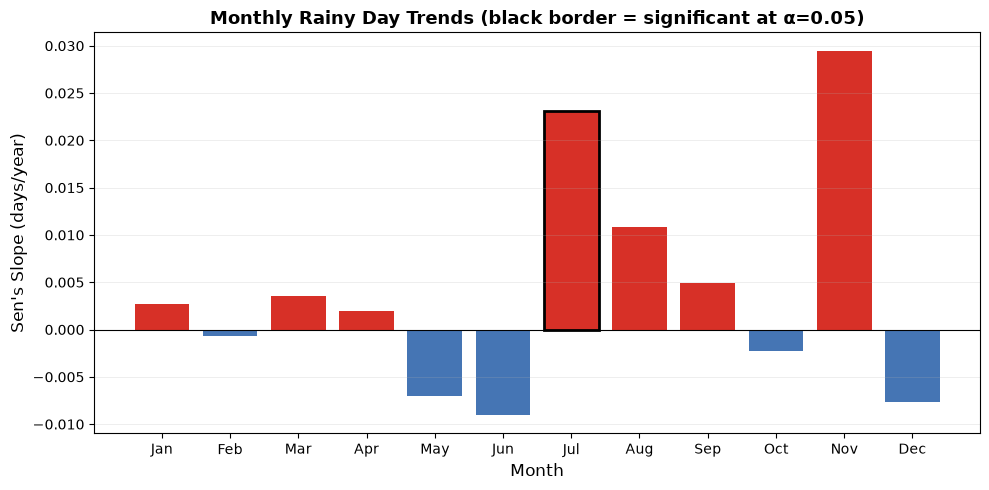

In [10]:
plot_monthly_trends(monthly_trends, output_path='../plots/monthly_trends.png')

## 5. Seasonal Forecasting Using Historical Patterns

Use interannual variability to generate probabilistic seasonal outlooks.

In [11]:
monthly_distributions = {}
for m in range(1, 13):
    monthly_vals = []
    for i in range(END_YEAR - START_YEAR + 1):
        idx = i * 12 + (m - 1)
        img = ee.Image(monthly_rainy_days.toList(monthly_rainy_days.size()).get(idx))
        mean_val = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi.geometry(),
            scale=5566,
            maxPixels=1e9
        ).get('rainy_day')
        monthly_vals.append(mean_val)

    values = ee.List(monthly_vals).getInfo()
    monthly_distributions[m] = np.array([v for v in values if v is not None], dtype=float)
    print(f'  {calendar.month_abbr[m]}: mean={np.mean(monthly_distributions[m]):.1f}, '
          f'std={np.std(monthly_distributions[m]):.1f}')

  Jan: mean=2.5, std=1.4
  Feb: mean=3.2, std=1.8
  Mar: mean=4.3, std=2.1
  Apr: mean=5.4, std=2.2
  May: mean=3.9, std=1.6
  Jun: mean=3.2, std=1.2
  Jul: mean=2.7, std=0.6
  Aug: mean=2.9, std=0.7
  Sep: mean=1.6, std=0.6
  Oct: mean=1.6, std=1.1
  Nov: mean=2.6, std=1.3
  Dec: mean=2.5, std=1.4


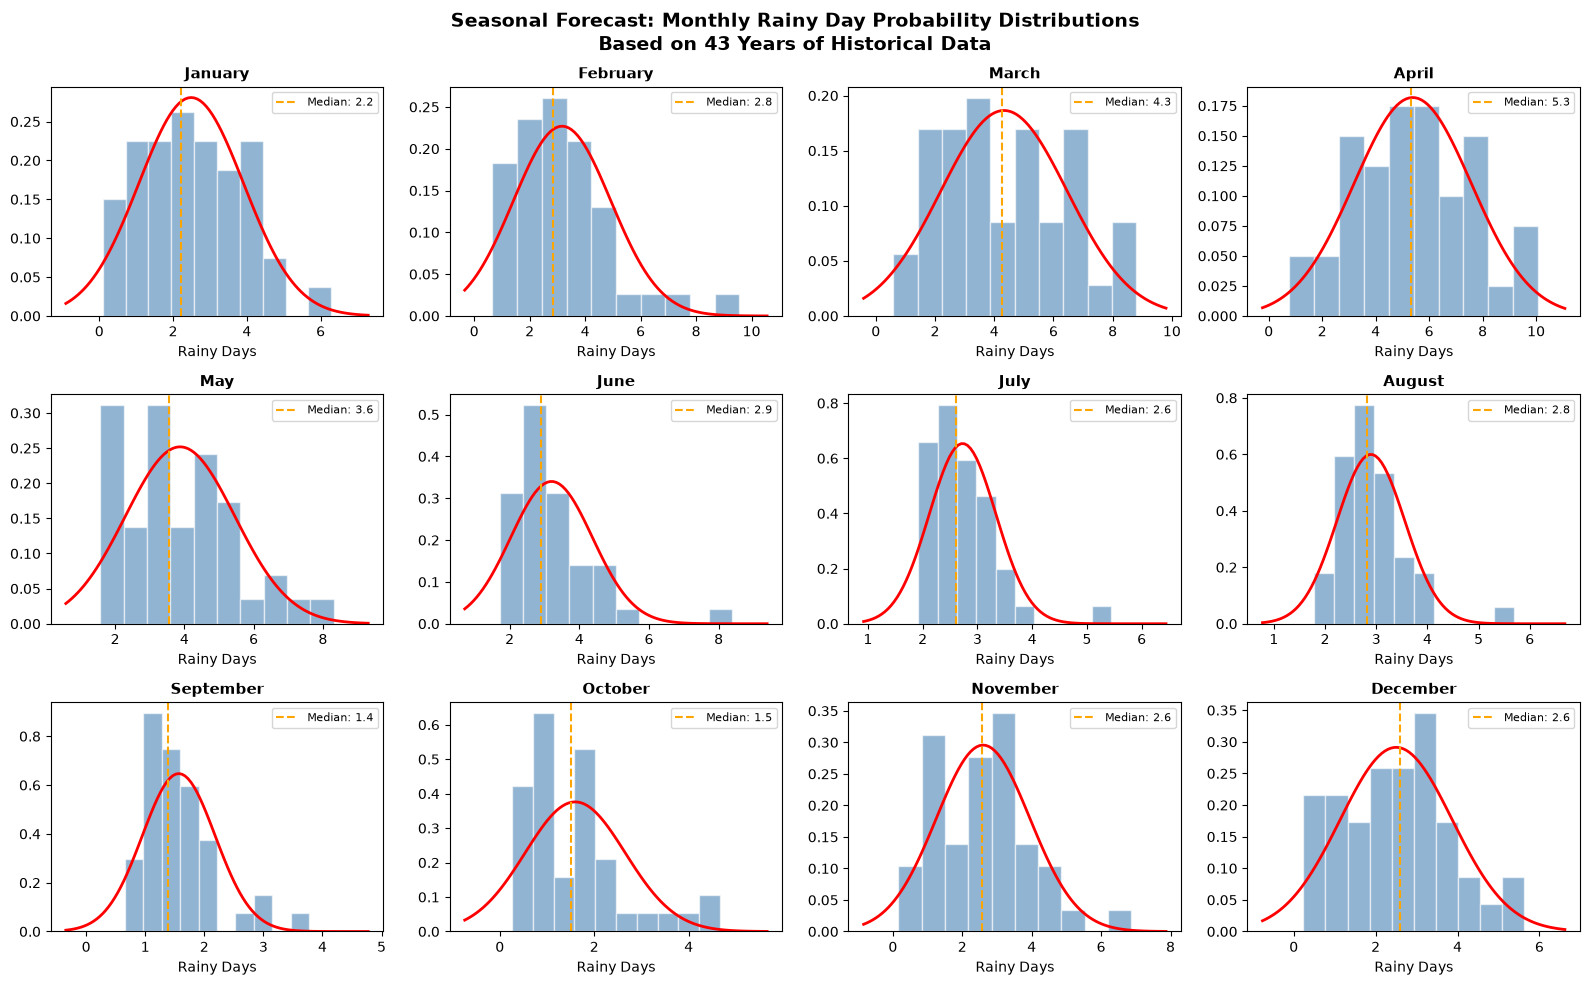

In [12]:
plot_seasonal_distributions(monthly_distributions, START_YEAR, END_YEAR,
                            output_path='../plots/seasonal_forecast_distributions.png')

In [13]:
# Tercile-based seasonal forecast summary
print('\n=== Tercile-Based Seasonal Outlook ===')
print(f'{"Month":<12} {"Below Normal":<16} {"Normal":<16} {"Above Normal":<16} {"Recent Trend"}')
print('-' * 72)

for m in range(1, 13):
    data = monthly_distributions[m]
    p33, p67 = np.percentile(data, [33, 67])
    recent_mean = np.mean(data[-10:])

    if recent_mean < p33:
        tendency = '↓ Drying'
    elif recent_mean > p67:
        tendency = '↑ Wetting'
    else:
        tendency = '→ Neutral'

    print(f'{calendar.month_name[m]:<12} <{p33:.1f} days       '
          f'{p33:.1f}–{p67:.1f} days    '
          f'>{p67:.1f} days       {tendency}')


=== Tercile-Based Seasonal Outlook ===
Month        Below Normal     Normal           Above Normal     Recent Trend
------------------------------------------------------------------------
January      <1.5 days       1.5–3.2 days    >3.2 days       → Neutral
February     <2.3 days       2.3–3.7 days    >3.7 days       → Neutral
March        <3.1 days       3.1–5.2 days    >5.2 days       → Neutral
April        <4.4 days       4.4–6.3 days    >6.3 days       → Neutral
May          <3.1 days       3.1–4.5 days    >4.5 days       → Neutral
June         <2.5 days       2.5–3.5 days    >3.5 days       ↑ Wetting
July         <2.5 days       2.5–2.8 days    >2.8 days       ↑ Wetting
August       <2.6 days       2.6–3.1 days    >3.1 days       ↑ Wetting
September    <1.2 days       1.2–1.7 days    >1.7 days       ↑ Wetting
October      <0.9 days       0.9–1.9 days    >1.9 days       → Neutral
November     <2.0 days       2.0–3.1 days    >3.1 days       ↑ Wetting
December     <1.9 days       

## 6. Multiple Precipitation Thresholds

Classify precipitation intensity: light (0–5 mm), moderate (5–20 mm), heavy (>20 mm).

In [14]:
THRESHOLDS = {
    'light': (0, 5),
    'moderate': (5, 20),
    'heavy': (20, None),
}
DAYS_IN_MONTH = [31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

threshold_monthly_means = compute_threshold_climatology(chirps, THRESHOLDS, aoi, DAYS_IN_MONTH)

# Print summary
print('\n=== Monthly Rainy Days by Intensity ===')
print(f'{"Month":<10} {"Light":<10} {"Moderate":<10} {"Heavy":<10} {"Total":<10}')
print('-' * 50)
for i in range(12):
    l, mod, h = (threshold_monthly_means['light'][i],
                 threshold_monthly_means['moderate'][i],
                 threshold_monthly_means['heavy'][i])
    print(f'{calendar.month_abbr[i+1]:<10} {l:<10.1f} {mod:<10.1f} {h:<10.1f} {l+mod+h:<10.1f}')


=== Monthly Rainy Days by Intensity ===
Month      Light      Moderate   Heavy      Total     
--------------------------------------------------
Jan        2.5        0.0        0.0        2.5       
Feb        3.2        0.0        0.0        3.2       
Mar        4.3        0.0        0.0        4.3       
Apr        5.4        0.0        0.0        5.4       
May        3.7        0.2        0.0        3.9       
Jun        1.7        1.5        0.0        3.2       
Jul        0.6        1.7        0.5        2.8       
Aug        0.5        1.9        0.5        2.9       
Sep        1.0        0.6        0.0        1.6       
Oct        1.5        0.1        0.0        1.6       
Nov        2.6        0.0        0.0        2.6       
Dec        2.5        0.0        0.0        2.5       


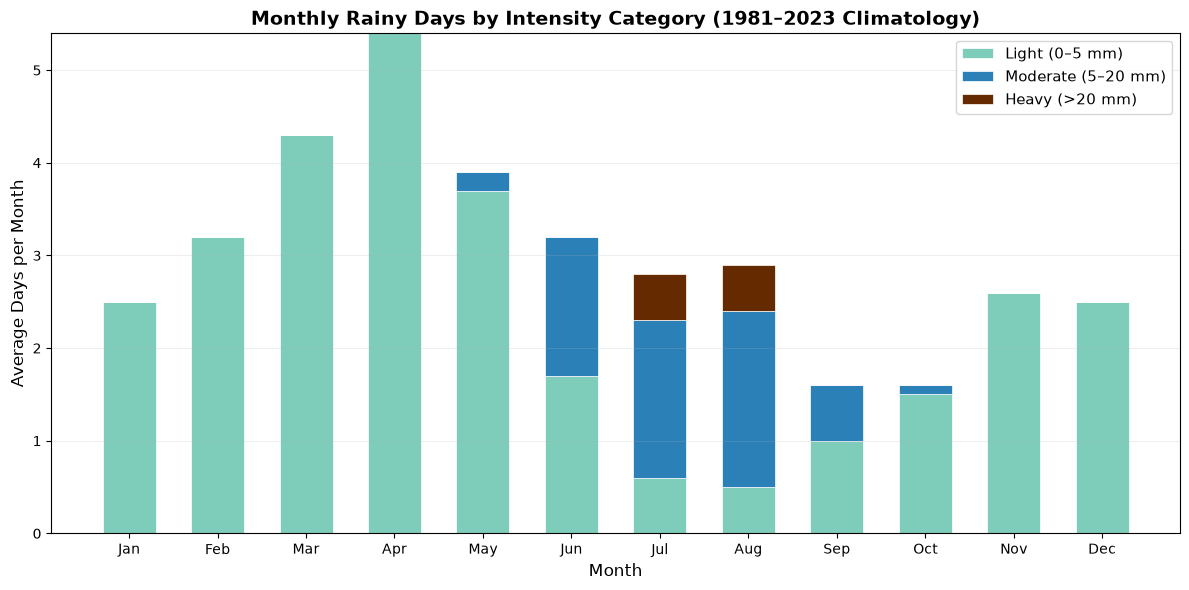

In [15]:
plot_threshold_stacked_bar(threshold_monthly_means, output_path='../plots/precipitation_thresholds.png')

## 7. Comparison with ERA5 and GPM Precipitation Datasets

Cross-validate CHIRPS against ERA5-Land (reanalysis) and GPM IMERG (satellite).

In [16]:
# Load comparison datasets
era5 = (
    ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
    .filterDate(ee.Date.fromYMD(2001, 1, 1), ee.Date.fromYMD(2023, 12, 31))
    .select('total_precipitation_sum')
)
gpm = (
    ee.ImageCollection('NASA/GPM_L3/IMERG_MONTHLY_V07')
    .filterDate(ee.Date.fromYMD(2001, 1, 1), ee.Date.fromYMD(2023, 12, 31))
    .select('precipitation')
)

# Compute monthly climatologies
chirps_clim = ee.ImageCollection.fromImages(months.map(
    lambda month: chirps.filter(ee.Filter.calendarRange(month, month, 'month')).mean().set({'month': month})
))
era5_clim = ee.ImageCollection.fromImages(months.map(
    lambda month: era5.filter(ee.Filter.calendarRange(month, month, 'month')).mean().multiply(1000).set({'month': month})
))
gpm_clim = ee.ImageCollection.fromImages(months.map(
    lambda month: gpm.filter(ee.Filter.calendarRange(month, month, 'month')).mean().multiply(24).set({'month': month})
))

# Extract values
chirps_monthly = extract_monthly_values(chirps_clim, 'precipitation', aoi)
era5_monthly = extract_monthly_values(era5_clim, 'total_precipitation_sum', aoi)
gpm_monthly = extract_monthly_values(gpm_clim, 'precipitation', aoi)

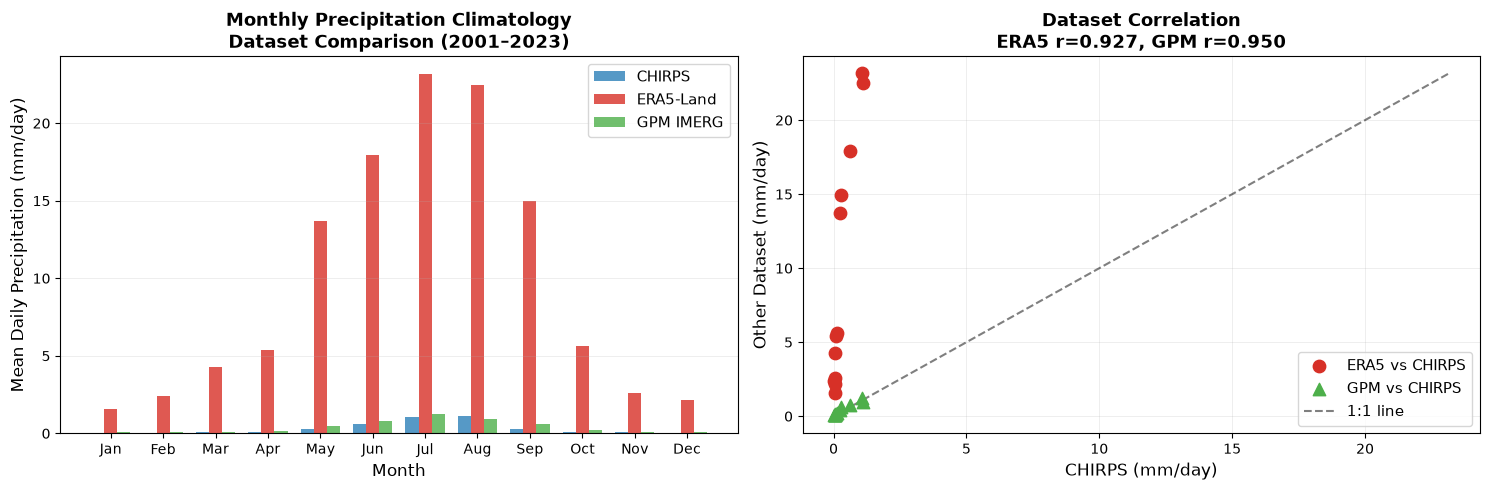


Correlation with CHIRPS: ERA5 r=0.927, GPM r=0.950


In [17]:
r_era5, r_gpm = plot_dataset_comparison(chirps_monthly, era5_monthly, gpm_monthly,
                                         output_path='../plots/dataset_comparison.png')

print(f'\nCorrelation with CHIRPS: ERA5 r={r_era5:.3f}, GPM r={r_gpm:.3f}')

## 8. Summary

| Step | Method | Scale |
|------|--------|-------|
| Data loading | GEE ImageCollection filtering | 15,700+ images |
| Feature engineering | Binary/threshold classification | Per-pixel, per-day |
| Temporal aggregation | Nested map-reduce | 504 monthly totals |
| Climatology | Multi-year mean | 12 monthly averages |
| Spatial processing | Vector clip | Custom AOI |
| Trend detection | Mann-Kendall test | 42-year time series |
| Forecasting | Historical distribution analysis | Tercile probabilities |
| Multi-dataset comparison | ERA5, GPM, CHIRPS | Cross-validation |

All computation runs server-side on Google's infrastructure — no large data downloads required.